# Mamba Model for Kalshi Trade-Level Jump Prediction

Train a Mamba sequence classifier on trade-level Kalshi prediction market data. This notebook does not resample, aggregate into bars, forward-fill, or recompute any features.

In [1]:
# Cell 1 - Setup and Drive mount
import os
import math
import random
import gc
from google.colab import drive

DRIVE_ROOT = '/content/drive'
DRIVE_MYDRIVE = os.path.join(DRIVE_ROOT, 'MyDrive')
os.makedirs(DRIVE_ROOT, exist_ok=True)
if os.path.isdir(DRIVE_MYDRIVE):
    print(f'Drive already available at {DRIVE_ROOT}')
else:
    mount_errors = []
    for force in [False, True]:
        try:
            drive.mount(DRIVE_ROOT, force_remount=force, timeout_ms=300000)
        except Exception as exc:
            mount_errors.append(f'force_remount={force}: {type(exc).__name__}: {exc}')
        if os.path.isdir(DRIVE_MYDRIVE):
            print(f'Drive mounted at {DRIVE_ROOT}')
            break
    else:
        print('Drive mount attempts failed:')
        for err in mount_errors:
            print('  ', err)
        print('Current /content/drive contents:', os.listdir(DRIVE_ROOT) if os.path.isdir(DRIVE_ROOT) else 'missing')
        raise RuntimeError('Google Drive is not mounted in this Colab VM. Restart the runtime and complete the Drive auth prompt.')

# No automatic pip installs or forced runtime restarts here. If a dependency is
# missing, install it manually in a separate cell, restart once, then rerun Cell 1.
import numpy as np
import pandas as pd
import pyarrow as pa
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Output path from notebooks/preprocessing_clean_m4.ipynb. Edit if your Drive path differs.
PARQUET_PATH = '/content/drive/MyDrive/CS1090B/project/data/all_trades_features.parquet'

print('Dependency versions:')
print('numpy:', np.__version__)
print('pandas:', pd.__version__)
print('pyarrow:', pa.__version__)
print('torch:', torch.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision('high')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


Mounted at /content/drive
Drive mounted at /content/drive
Dependency versions:
numpy: 2.0.2
pandas: 2.2.2
pyarrow: 18.1.0
torch: 2.10.0+cu128
Using device: cuda
NVIDIA RTX PRO 6000 Blackwell Server Edition


In [2]:
# Cell 1b - Install Mamba dependencies if missing
# Run this once in a fresh Colab runtime before Cell 5.
# Uses try/import (not find_spec) so it reinstalls if compiled CUDA extensions are broken.
import sys
import subprocess

try:
    from mamba_ssm import Mamba
    print('mamba_ssm import OK')
except Exception as exc:
    print(f'Installing mamba-ssm (reason: {exc})...')
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', '--no-cache-dir', '--no-build-isolation',
        'packaging', 'ninja', 'causal-conv1d', 'mamba-ssm'
    ])
    # Purge the pip build cache to reclaim disk space after compilation.
    subprocess.call([sys.executable, '-m', 'pip', 'cache', 'purge'])
    from mamba_ssm import Mamba
    print('mamba_ssm import OK after install')

Installing mamba-ssm (reason: No module named 'mamba_ssm')...
mamba_ssm import OK after install


In [3]:
# Cell 2 - Load data
df = pd.read_parquet(PARQUET_PATH)

TARGET_COLUMNS = ['jump3_5m', 'jump3_15m', 'jump3_30m', 'jump3_60m']
HORIZON_NAMES = ['5m', '15m', '30m', '60m']
CLASS_NAMES = ['down', 'none', 'up']

# Must match FEATURE_COLS from notebooks/preprocessing_clean_m4.ipynb exactly.
# That preprocessing notebook produces 40 model features: 16 dynamic + 8 backward-return
# features + 8 recent-jump-count features + 8 ticker embedding features.
FEATURE_COLUMNS = [
    'yes_price',
    'log_volume',
    'log_time_delta',
    'ret_last_5',
    'ret_last_10',
    'ret_last_20',
    'position_in_range',
    'dist_from_50',
    'relative_volume',
    'tick',
    'run_length',
    'volume_since_price_change',
    'trades_last_60s',
    'trades_last_300s',
    'hour_sin',
    'hour_cos',
    'backward_ret_5m',
    'backward_ret_15m',
    'backward_ret_30m',
    'backward_ret_60m',
    'backward_abs_ret_5m',
    'backward_abs_ret_15m',
    'backward_abs_ret_30m',
    'backward_abs_ret_60m',
    'recent_up_jumps_5m',
    'recent_up_jumps_15m',
    'recent_up_jumps_30m',
    'recent_up_jumps_60m',
    'recent_down_jumps_5m',
    'recent_down_jumps_15m',
    'recent_down_jumps_30m',
    'recent_down_jumps_60m',
    *[f'ticker_emb_{i}' for i in range(8)],
]

missing_feature_columns = [c for c in FEATURE_COLUMNS if c not in df.columns]
missing_required_columns = [c for c in ['ticker', 'created_time', *TARGET_COLUMNS] if c not in df.columns]
if missing_required_columns:
    raise ValueError(f'Missing required columns: {missing_required_columns}')
if missing_feature_columns:
    raise ValueError(f'Missing feature columns from preprocessing schema: {missing_feature_columns}')
INPUT_DIM = len(FEATURE_COLUMNS)
assert INPUT_DIM == 40, f'Expected 40 preprocessing features, found {INPUT_DIM}'

print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print(f'\nInput feature count: {INPUT_DIM}')
print('Feature columns:', FEATURE_COLUMNS)

feature_nan_counts = df[FEATURE_COLUMNS].isna().sum().sort_values(ascending=False)
feature_inf_counts = np.isinf(df[FEATURE_COLUMNS].select_dtypes(include=[np.number])).sum().sort_values(ascending=False)
print('\nTop feature NaN counts:')
print(feature_nan_counts.head(15).to_string())
print('\nTop feature inf counts:')
print(feature_inf_counts.head(15).to_string())

if pd.api.types.is_numeric_dtype(df['created_time']):
    date_series = pd.to_datetime(df['created_time'], unit='us', utc=True, errors='coerce')
else:
    date_series = pd.to_datetime(df['created_time'], utc=True, errors='coerce')
print('\nDate range:')
print('min:', date_series.min())
print('max:', date_series.max())
print('\nUnique tickers:', df['ticker'].nunique())

print('\nClass balance by target:')
for col in TARGET_COLUMNS:
    counts = df[col].value_counts(dropna=False).sort_index()
    pct = df[col].value_counts(normalize=True, dropna=False).sort_index() * 100
    balance = pd.DataFrame({'count': counts, 'pct': pct.round(3)})
    print(f'\n{col}')
    print(balance)

Shape: (63801798, 63)

Dtypes:
ticker                       category
yes_price                       int64
no_price                        int64
count                           int64
taker_side                     object
                               ...   
volume_since_price_change     float32
trades_last_60s               float32
trades_last_300s              float32
hour_sin                      float32
hour_cos                      float32
Length: 63, dtype: object

Input feature count: 40
Feature columns: ['yes_price', 'log_volume', 'log_time_delta', 'ret_last_5', 'ret_last_10', 'ret_last_20', 'position_in_range', 'dist_from_50', 'relative_volume', 'tick', 'run_length', 'volume_since_price_change', 'trades_last_60s', 'trades_last_300s', 'hour_sin', 'hour_cos', 'backward_ret_5m', 'backward_ret_15m', 'backward_ret_30m', 'backward_ret_60m', 'backward_abs_ret_5m', 'backward_abs_ret_15m', 'backward_abs_ret_30m', 'backward_abs_ret_60m', 'recent_up_jumps_5m', 'recent_up_jumps_15m', 'rec

In [4]:
# Cell 3 - Sequence dataset
# IMPORTANT: windows must never mix tickers. Each sequence below is built only from trades
# belonging to one ticker, sorted by created_time. There is no resampling, no ffill,
# no bar construction, and no recomputation of log_time_delta or any other feature.
# Windows with NaN/inf feature values are dropped. This avoids leakage-prone filling while
# handling early per-ticker rows where preprocessing naturally cannot compute lag features.

class KalshiSequenceDataset(Dataset):
    def __init__(
        self,
        frame,
        feature_cols,
        target_cols,
        seq_len,
        stride,
        max_sequences=None,
        random_state=42,
        feature_mean=None,
        feature_std=None,
    ):
        self.feature_cols = list(feature_cols)
        self.target_cols = list(target_cols)
        self.seq_len = int(seq_len)
        self.stride = int(stride)
        self.groups = []
        self.feature_mean = None if feature_mean is None else np.asarray(feature_mean, dtype=np.float32)
        self.feature_std = None if feature_std is None else np.asarray(feature_std, dtype=np.float32)

        group_ids = []
        starts = []
        sequence_labels = []
        rng = np.random.default_rng(random_state)

        for ticker, group in frame.groupby('ticker', sort=False, observed=True):
            group = group.sort_values('created_time', kind='mergesort')
            n = len(group)
            if n < self.seq_len:
                continue

            features = group[self.feature_cols].to_numpy(dtype=np.float32, copy=True)
            if self.feature_mean is not None and self.feature_std is not None:
                features = (features - self.feature_mean) / self.feature_std
            raw_labels = group[self.target_cols].to_numpy(copy=True)
            valid_label_rows = ~pd.isna(raw_labels).any(axis=1)
            valid_feature_rows = np.isfinite(features).all(axis=1)
            valid_feature_prefix = np.concatenate([[0], np.cumsum(valid_feature_rows, dtype=np.int32)])

            labels = np.full(raw_labels.shape, -100, dtype=np.int64)
            labels[raw_labels == -1] = 0
            labels[raw_labels == 0] = 1
            labels[raw_labels == 1] = 2
            valid_label_rows &= (labels >= 0).all(axis=1)

            end_positions = np.arange(self.seq_len - 1, n, self.stride, dtype=np.int64)
            starts_for_filter = end_positions - self.seq_len + 1
            valid_window_features = (
                valid_feature_prefix[end_positions + 1] - valid_feature_prefix[starts_for_filter]
            ) == self.seq_len
            end_positions = end_positions[valid_label_rows[end_positions] & valid_window_features]
            if len(end_positions) == 0:
                continue

            group_idx = len(self.groups)
            self.groups.append({'ticker': ticker, 'features': features})
            group_ids.append(np.full(len(end_positions), group_idx, dtype=np.int32))
            starts.append((end_positions - self.seq_len + 1).astype(np.int32))
            sequence_labels.append(labels[end_positions].astype(np.int64))

        if not group_ids:
            self.group_ids = np.empty(0, dtype=np.int32)
            self.starts = np.empty(0, dtype=np.int32)
            self.sequence_labels = np.empty((0, len(self.target_cols)), dtype=np.int64)
            return

        self.group_ids = np.concatenate(group_ids)
        self.starts = np.concatenate(starts)
        self.sequence_labels = np.concatenate(sequence_labels, axis=0)

        if max_sequences is not None and len(self.group_ids) > max_sequences:
            keep = rng.choice(len(self.group_ids), size=int(max_sequences), replace=False)
            self.group_ids = self.group_ids[keep]
            self.starts = self.starts[keep]
            self.sequence_labels = self.sequence_labels[keep]

    def __len__(self):
        return len(self.group_ids)

    def __getitem__(self, idx):
        group = self.groups[int(self.group_ids[idx])]
        start = int(self.starts[idx])
        end = start + self.seq_len
        x = torch.from_numpy(group['features'][start:end])
        y = torch.from_numpy(self.sequence_labels[idx])
        return x, y

    def label_counts(self, indices=None):
        labels = self.sequence_labels if indices is None else self.sequence_labels[np.asarray(indices)]
        counts = np.zeros((len(self.target_cols), 3), dtype=np.int64)
        for h in range(len(self.target_cols)):
            counts[h] = np.bincount(labels[:, h], minlength=3)[:3]
        return counts

In [5]:
# Cell 4 - Train/validation/test split
# preprocessing_clean_m4.ipynb writes a temporal train/test split after computing
# train-only jump thresholds. If it has no val split, carve validation from the
# end of the preprocessing train period and leave the future test period untouched.
ORIGINAL_N = len(df)
MODEL_VAL_FRACTION_OF_PREPROCESS_TRAIN = 0.10

if 'split' in df.columns:
    split_col = df['split'].astype(str).str.lower()
    if split_col.eq('val').any():
        train_mask = split_col.eq('train')
        val_mask = split_col.eq('val')
        test_mask = split_col.eq('test')
        print('Using saved train/val/test split column from preprocessing.')
    else:
        pre_train_mask = split_col.eq('train')
        test_mask = split_col.eq('test')
        val_cutoff = date_series.loc[pre_train_mask].quantile(1.0 - MODEL_VAL_FRACTION_OF_PREPROCESS_TRAIN)
        train_mask = pre_train_mask & (date_series < val_cutoff)
        val_mask = pre_train_mask & (date_series >= val_cutoff)
        print('Using saved preprocessing train/test split; carving validation from the end of preprocessing train.')
else:
    train_cutoff = date_series.quantile(0.70)
    val_cutoff = date_series.quantile(0.80)
    train_mask = date_series < train_cutoff
    val_mask = (date_series >= train_cutoff) & (date_series < val_cutoff)
    test_mask = date_series >= val_cutoff
    print('No split column found; using fallback 70/10/20 temporal split.')

if not train_mask.any() or not val_mask.any() or not test_mask.any():
    raise ValueError('Train/val/test split produced an empty side. Check split or created_time values.')

# Keep only columns needed by the sequence model to reduce Colab RAM pressure.
MODEL_COLUMNS = ['ticker', 'created_time', *FEATURE_COLUMNS, *TARGET_COLUMNS]
train_df = df.loc[train_mask, MODEL_COLUMNS].copy()
val_df = df.loc[val_mask, MODEL_COLUMNS].copy()
test_df = df.loc[test_mask, MODEL_COLUMNS].copy()
train_end = date_series.loc[train_mask].max()
val_start = date_series.loc[val_mask].min()
val_end = date_series.loc[val_mask].max()
test_start = date_series.loc[test_mask].min()
del df
gc.collect()

print('Train end:', train_end)
print('Val start/end:', val_start, '->', val_end)
print('Test start:', test_start)
print('Train trades:', len(train_df))
print('Val trades:', len(val_df))
print('Test trades:', len(test_df))
print('Train pct:', round(100 * len(train_df) / ORIGINAL_N, 3))
print('Val pct:', round(100 * len(val_df) / ORIGINAL_N, 3))
print('Test pct:', round(100 * len(test_df) / ORIGINAL_N, 3))

Using saved preprocessing train/test split; carving validation from the end of preprocessing train.
Train end: 2025-10-29 02:41:31.136746+00:00
Val start/end: 2025-10-29 02:41:31.323698+00:00 -> 2025-11-06 03:58:08.005510+00:00
Test start: 2025-11-06 03:58:08.028990+00:00
Train trades: 45937294
Val trades: 5104144
Test trades: 12760360
Train pct: 72.0
Val pct: 8.0
Test pct: 20.0


In [6]:
# Cell 5 - Model definition and editable hyperparameters
from mamba_ssm import Mamba

# Defaults tuned for a Colab G4/L4-class GPU. On A100, try D_MODEL=128,
# N_LAYERS=4, and BATCH_SIZE=512.
SEQ_LEN = 32        # Start here; 64 is the next thing to try.
STRIDE = 16
D_MODEL = 96
D_STATE = 16
D_CONV = 4
EXPAND = 2
N_LAYERS = 3
BATCH_SIZE = 256
LR = 3e-4
EPOCHS = 10
MAX_SEQUENCES = None  # Use every valid sequence. Set an int only for quick smoke tests.
WARMUP_STEPS = 500
USE_AMP = False  # Keep off until train_loss is finite; turn on later for speed.
USE_CLASS_WEIGHTS = True
NUM_WORKERS = 2
CHECKPOINT_DIR = '/content/drive/MyDrive/CS1090B/project/checkpoints'
BEST_CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'mamba_best.pt')
LEGACY_CHECKPOINT_PATH = '/content/mamba_best.pt'
FIGURE_DIR = '/content/drive/MyDrive/CS1090B/project/figures/mamba'
RUN_TRAINING = False   # Set True to retrain from scratch.
RUN_EVALUATION = True  # Set True to build test_dataset and run Cell 7 metrics/figures.

class MambaJumpPredictor(nn.Module):
    def __init__(self, input_dim, d_model, d_state, d_conv, expand, n_layers, n_horizons=4, n_classes=3):
        super().__init__()
        self.n_horizons = n_horizons
        self.n_classes = n_classes
        self.input_proj = nn.Linear(input_dim, d_model)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'norm': nn.LayerNorm(d_model),
                'mamba': Mamba(d_model=d_model, d_state=d_state, d_conv=d_conv, expand=expand),
            })
            for _ in range(n_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_horizons * n_classes)

    def forward(self, x):
        x = self.input_proj(x)
        for layer in self.layers:
            x = x + layer['mamba'](layer['norm'](x))
        x = self.final_norm(x)
        last_hidden = x[:, -1, :]
        logits = self.head(last_hidden)
        return logits.view(-1, self.n_horizons, self.n_classes)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = MambaJumpPredictor(
    input_dim=INPUT_DIM,
    d_model=D_MODEL,
    d_state=D_STATE,
    d_conv=D_CONV,
    expand=EXPAND,
    n_layers=N_LAYERS,
).to(device)

print(model)
print(f'Trainable parameters: {count_parameters(model):,}')

MambaJumpPredictor(
  (input_proj): Linear(in_features=40, out_features=96, bias=True)
  (layers): ModuleList(
    (0-2): 3 x ModuleDict(
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (mamba): Mamba(
        (in_proj): Linear(in_features=96, out_features=384, bias=False)
        (conv1d): Conv1d(192, 192, kernel_size=(4,), stride=(1,), padding=(3,), groups=192)
        (act): SiLU()
        (x_proj): Linear(in_features=192, out_features=38, bias=False)
        (dt_proj): Linear(in_features=6, out_features=192, bias=True)
        (out_proj): Linear(in_features=192, out_features=96, bias=False)
      )
    )
  )
  (final_norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=96, out_features=12, bias=True)
)
Trainable parameters: 210,348


In [7]:
# Cell 6 - Training loop (or fast checkpoint load when RUN_TRAINING=False)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f'Checkpoints will be saved to: {BEST_CHECKPOINT_PATH}')

if RUN_TRAINING:
    # Full path: compute normalization stats from train data, build all datasets, and train.
    train_feature_frame = train_df[FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
    FEATURE_MEAN = train_feature_frame.mean(axis=0).astype(np.float32).to_numpy()
    FEATURE_STD = train_feature_frame.std(axis=0).replace(0, 1).fillna(1).astype(np.float32).to_numpy()
    del train_feature_frame
    gc.collect()

    print('Building sequence datasets...')
    train_dataset = KalshiSequenceDataset(
        train_df,
        feature_cols=FEATURE_COLUMNS,
        target_cols=TARGET_COLUMNS,
        seq_len=SEQ_LEN,
        stride=STRIDE,
        max_sequences=MAX_SEQUENCES,
        random_state=SEED,
        feature_mean=FEATURE_MEAN,
        feature_std=FEATURE_STD,
    )
    val_dataset = KalshiSequenceDataset(
        val_df,
        feature_cols=FEATURE_COLUMNS,
        target_cols=TARGET_COLUMNS,
        seq_len=SEQ_LEN,
        stride=STRIDE,
        max_sequences=MAX_SEQUENCES,
        random_state=SEED + 1,
        feature_mean=FEATURE_MEAN,
        feature_std=FEATURE_STD,
    )
    test_dataset = KalshiSequenceDataset(
        test_df,
        feature_cols=FEATURE_COLUMNS,
        target_cols=TARGET_COLUMNS,
        seq_len=SEQ_LEN,
        stride=STRIDE,
        max_sequences=MAX_SEQUENCES,
        random_state=SEED + 2,
        feature_mean=FEATURE_MEAN,
        feature_std=FEATURE_STD,
    )
    print(f'Train sequences: {len(train_dataset):,}')
    print(f'Val sequences: {len(val_dataset):,}')
    print(f'Test sequences: {len(test_dataset):,}')

    if len(train_dataset) == 0:
        raise ValueError('No train sequences were created. Check SEQ_LEN, STRIDE, target labels, and ticker lengths.')
    if len(val_dataset) == 0:
        raise ValueError('No val sequences were created. Check temporal split, SEQ_LEN, target labels, and ticker lengths.')
    if len(test_dataset) == 0:
        raise ValueError('No test sequences were created. Check temporal split, SEQ_LEN, target labels, and ticker lengths.')

    pin_memory = device.type == 'cuda'
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
        persistent_workers=NUM_WORKERS > 0,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
        persistent_workers=NUM_WORKERS > 0,
    )

    train_counts = train_dataset.label_counts()
    print('Training label counts by horizon, columns=[down, none, up]:')
    for horizon, counts in zip(HORIZON_NAMES, train_counts):
        print(horizon, counts.tolist())

    class_weights_np = train_counts.sum(axis=1, keepdims=True) / (3.0 * np.maximum(train_counts, 1))
    class_weights_np = class_weights_np / class_weights_np.mean(axis=1, keepdims=True)
    class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=device)
    if USE_CLASS_WEIGHTS:
        criteria = [nn.CrossEntropyLoss(weight=class_weights[h]) for h in range(4)]
    else:
        criteria = [nn.CrossEntropyLoss() for _ in range(4)]
    print('Class weights by horizon, columns=[down, none, up]:')
    print(class_weights.detach().cpu().numpy())

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    total_steps = max(1, EPOCHS * len(train_loader))

    def lr_lambda(step):
        if step < WARMUP_STEPS:
            return float(step + 1) / float(max(1, WARMUP_STEPS))
        progress = float(step - WARMUP_STEPS) / float(max(1, total_steps - WARMUP_STEPS))
        return 0.5 * (1.0 + math.cos(math.pi * min(1.0, progress)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda' and USE_AMP))

    def compute_loss(logits, labels):
        losses = [criteria[h](logits[:, h, :], labels[:, h]) for h in range(4)]
        return torch.stack(losses).mean()

    @torch.no_grad()
    def validate(model, loader):
        model.eval()
        all_preds = []
        all_labels = []
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda' and USE_AMP)):
                logits = model(x)
            preds = logits.argmax(dim=-1)
            all_preds.append(preds.detach().cpu().numpy())
            all_labels.append(y.detach().cpu().numpy())
        y_pred = np.concatenate(all_preds, axis=0)
        y_true = np.concatenate(all_labels, axis=0)
        acc = np.array([accuracy_score(y_true[:, h], y_pred[:, h]) for h in range(4)])
        macro_f1 = np.array([
            f1_score(y_true[:, h], y_pred[:, h], labels=[0, 1, 2], average='macro', zero_division=0)
            for h in range(4)
        ])
        pred_counts = np.stack([np.bincount(y_pred[:, h], minlength=3)[:3] for h in range(4)])
        return acc, macro_f1, pred_counts

    best_mean_val_macro_f1 = -1.0
    global_step = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        seen = 0

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            if not torch.isfinite(x).all():
                raise ValueError('Non-finite input batch encountered after dataset filtering/normalization.')
            if not ((y >= 0) & (y <= 2)).all():
                raise ValueError('Invalid target label encountered. Expected labels in {0, 1, 2}.')

            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda' and USE_AMP)):
                logits = model(x)
                loss = compute_loss(logits, y)
            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f'Non-finite loss at epoch={epoch}, step={global_step}. '
                    'Do not continue training from this run; lower LR, keep USE_AMP=False, and inspect inputs.'
                )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            batch_size = y.size(0)
            running_loss += loss.item() * batch_size
            seen += batch_size
            global_step += 1

        train_loss = running_loss / max(1, seen)
        val_acc, val_macro_f1, val_pred_counts = validate(model, val_loader)
        mean_val_acc = float(val_acc.mean())
        mean_val_macro_f1 = float(val_macro_f1.mean())
        acc_text = ', '.join([f'{h}: {a:.4f}' for h, a in zip(HORIZON_NAMES, val_acc)])
        f1_text = ', '.join([f'{h}: {a:.4f}' for h, a in zip(HORIZON_NAMES, val_macro_f1)])
        print(f'Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.5f} | val_acc_mean={mean_val_acc:.4f} | val_macro_f1_mean={mean_val_macro_f1:.4f}')
        print(f'  val_acc      | {acc_text}')
        print(f'  val_macro_f1 | {f1_text}')
        print('  val prediction counts by horizon, columns=[down, none, up]:')
        for horizon, counts in zip(HORIZON_NAMES, val_pred_counts):
            print(f'    {horizon}: {counts.tolist()}')

        if mean_val_macro_f1 > best_mean_val_macro_f1:
            best_mean_val_macro_f1 = mean_val_macro_f1
            torch.save(
                {
                    'model_state_dict': model.state_dict(),
                    'input_dim': INPUT_DIM,
                    'feature_columns': FEATURE_COLUMNS,
                    'target_columns': TARGET_COLUMNS,
                    'feature_mean': FEATURE_MEAN,
                    'feature_std': FEATURE_STD,
                    'hyperparameters': {
                        'SEQ_LEN': SEQ_LEN,
                        'STRIDE': STRIDE,
                        'D_MODEL': D_MODEL,
                        'D_STATE': D_STATE,
                        'D_CONV': D_CONV,
                        'EXPAND': EXPAND,
                        'N_LAYERS': N_LAYERS,
                        'LR': LR,
                        'USE_AMP': USE_AMP,
                        'USE_CLASS_WEIGHTS': USE_CLASS_WEIGHTS,
                    },
                    'best_mean_val_acc': mean_val_acc,
                    'best_mean_val_macro_f1': best_mean_val_macro_f1,
                },
                BEST_CHECKPOINT_PATH,
            )
            print(f'  saved best checkpoint to {BEST_CHECKPOINT_PATH}')

else:
    # Checkpoint path: load weights and normalization stats directly from the saved checkpoint.
    # Skips train/val dataset building entirely — the main source of the multi-hour wait.
    existing_checkpoint = next((p for p in [BEST_CHECKPOINT_PATH, LEGACY_CHECKPOINT_PATH] if os.path.exists(p)), None)
    if existing_checkpoint is None:
        raise FileNotFoundError('RUN_TRAINING=False but no checkpoint was found. Set RUN_TRAINING=True to train.')
    BEST_CHECKPOINT_PATH = existing_checkpoint
    checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=device, weights_only=False)
    FEATURE_MEAN = checkpoint.get('feature_mean', None)
    FEATURE_STD = checkpoint.get('feature_std', None)
    if FEATURE_MEAN is None or FEATURE_STD is None:
        raise KeyError('Checkpoint is missing feature_mean/feature_std; cannot run inference consistently.')
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    print(f'Loaded existing checkpoint, skipping training: {BEST_CHECKPOINT_PATH}')

    if RUN_EVALUATION:
        print('Building test dataset only (skipping train/val to save time)...')
        test_dataset = KalshiSequenceDataset(
            test_df,
            feature_cols=FEATURE_COLUMNS,
            target_cols=TARGET_COLUMNS,
            seq_len=SEQ_LEN,
            stride=STRIDE,
            max_sequences=MAX_SEQUENCES,
            random_state=SEED + 2,
            feature_mean=FEATURE_MEAN,
            feature_std=FEATURE_STD,
        )
        print(f'Test sequences: {len(test_dataset):,}')
        if len(test_dataset) == 0:
            raise ValueError('No test sequences were created. Check SEQ_LEN, STRIDE, target labels, and ticker lengths.')

Checkpoints will be saved to: /content/drive/MyDrive/CS1090B/project/checkpoints/mamba_best.pt
Loaded existing checkpoint, skipping training: /content/drive/MyDrive/CS1090B/project/checkpoints/mamba_best.pt
Building test dataset only (skipping train/val to save time)...
Test sequences: 536,890


Loaded checkpoint: /content/drive/MyDrive/CS1090B/project/checkpoints/mamba_best.pt
Figures will be saved to: /content/drive/MyDrive/CS1090B/project/figures/mamba

=== Horizon 5m ===
Accuracy: 0.5829 | Macro F1: 0.4456 | Weighted F1: 0.6398
              precision    recall  f1-score   support

        down     0.2319    0.4553    0.3073     63593
        none     0.9292    0.6226    0.7457    410544
          up     0.2070    0.4518    0.2840     62753

    accuracy                         0.5829    536890
   macro avg     0.4561    0.5099    0.4456    536890
weighted avg     0.7622    0.5829    0.6398    536890


=== Horizon 15m ===
Accuracy: 0.6195 | Macro F1: 0.4796 | Weighted F1: 0.6632
              precision    recall  f1-score   support

        down     0.2713    0.4436    0.3367     69658
        none     0.9167    0.6766    0.7785    398742
          up     0.2479    0.4659    0.3236     68490

    accuracy                         0.6195    536890
   macro avg     0.4786    

horizon,5m,15m,30m,60m
accuracy,0.582861,0.619466,0.645052,0.645693
macro_f1,0.445643,0.479614,0.502910,0.507804
weighted_f1,0.639770,0.663175,0.679494,0.680154


Saved /content/drive/MyDrive/CS1090B/project/figures/mamba/mamba_confusion_matrices_normalized.png
Saved /content/drive/MyDrive/CS1090B/project/figures/mamba/mamba_confusion_matrices_normalized.pdf


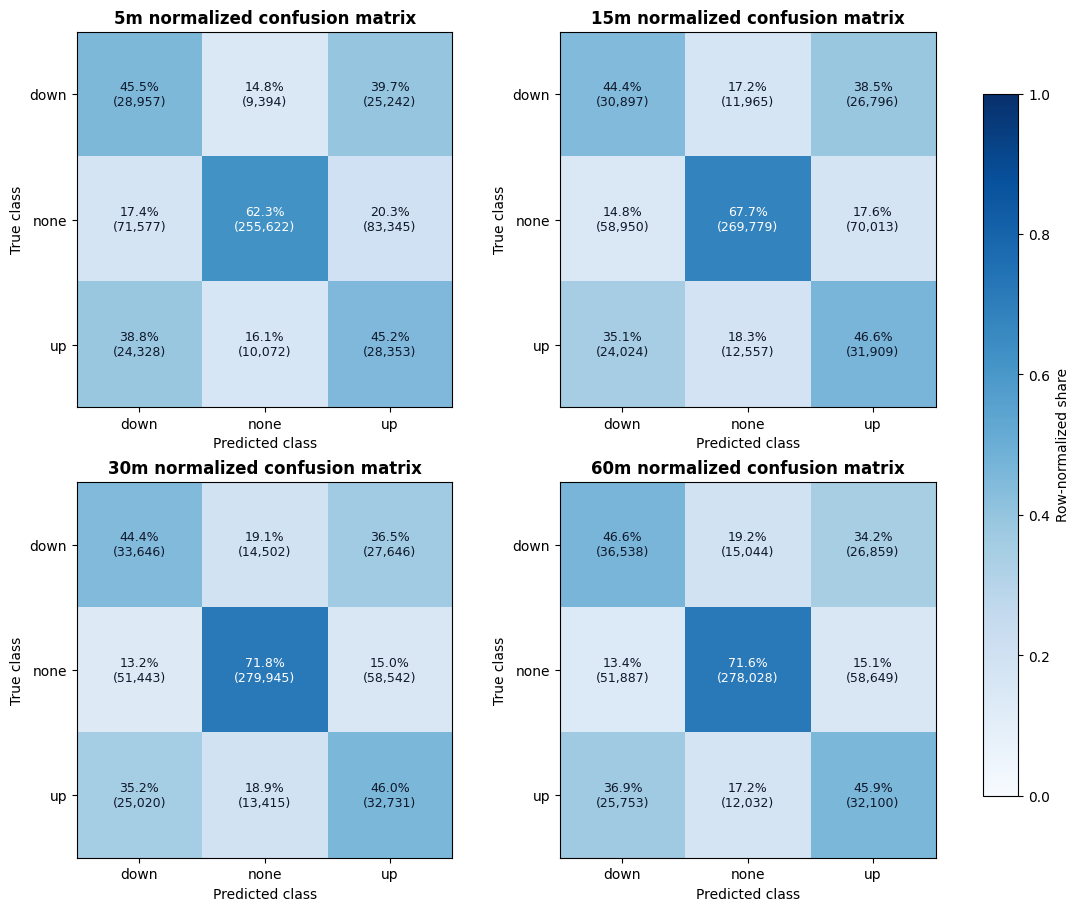

Saved /content/drive/MyDrive/CS1090B/project/figures/mamba/mamba_summary_metrics.png
Saved /content/drive/MyDrive/CS1090B/project/figures/mamba/mamba_summary_metrics.pdf


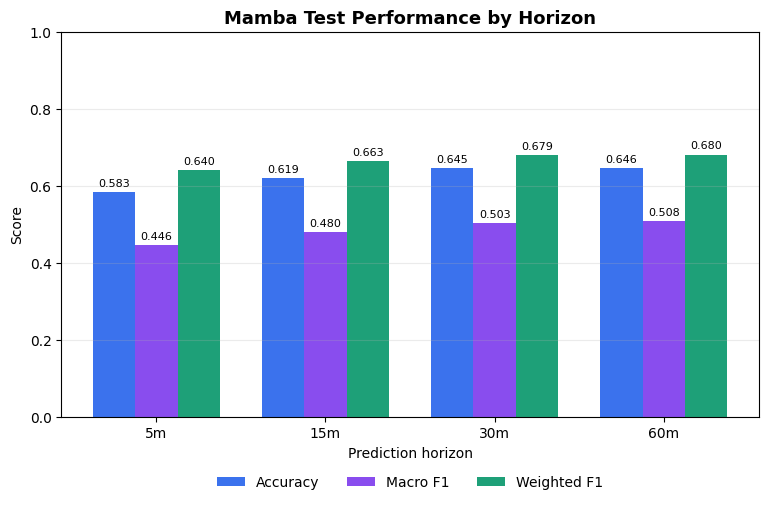

Saved /content/drive/MyDrive/CS1090B/project/figures/mamba/mamba_per_class_f1.png
Saved /content/drive/MyDrive/CS1090B/project/figures/mamba/mamba_per_class_f1.pdf


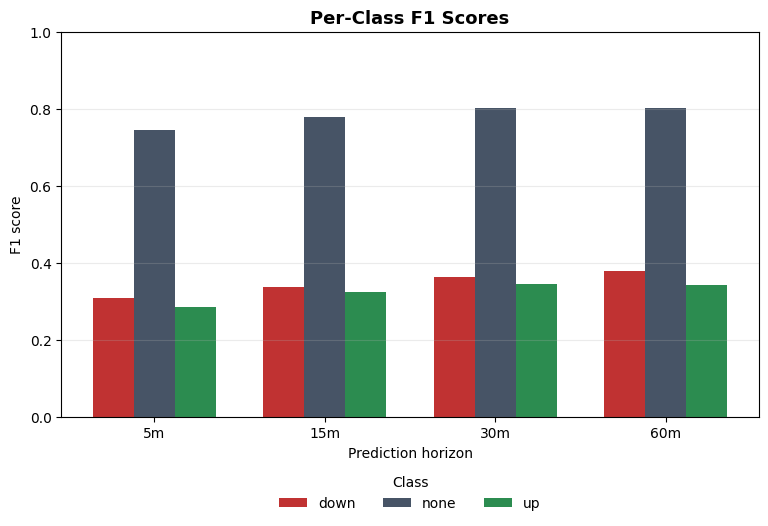

Saved /content/drive/MyDrive/CS1090B/project/figures/mamba/mamba_class_distribution.png
Saved /content/drive/MyDrive/CS1090B/project/figures/mamba/mamba_class_distribution.pdf


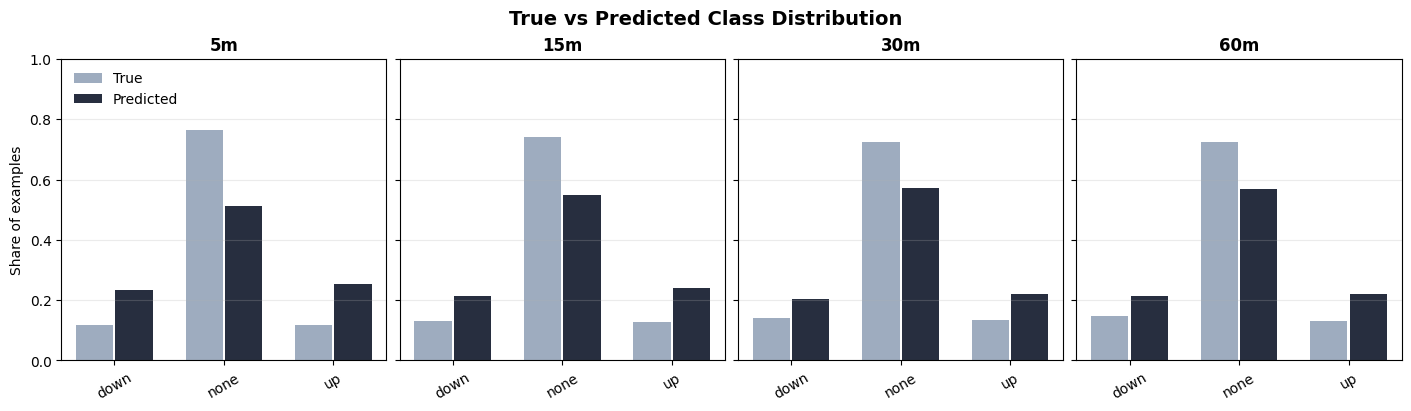

Saved /content/drive/MyDrive/CS1090B/project/figures/mamba/mamba_mean_probabilities_by_true_class.png
Saved /content/drive/MyDrive/CS1090B/project/figures/mamba/mamba_mean_probabilities_by_true_class.pdf


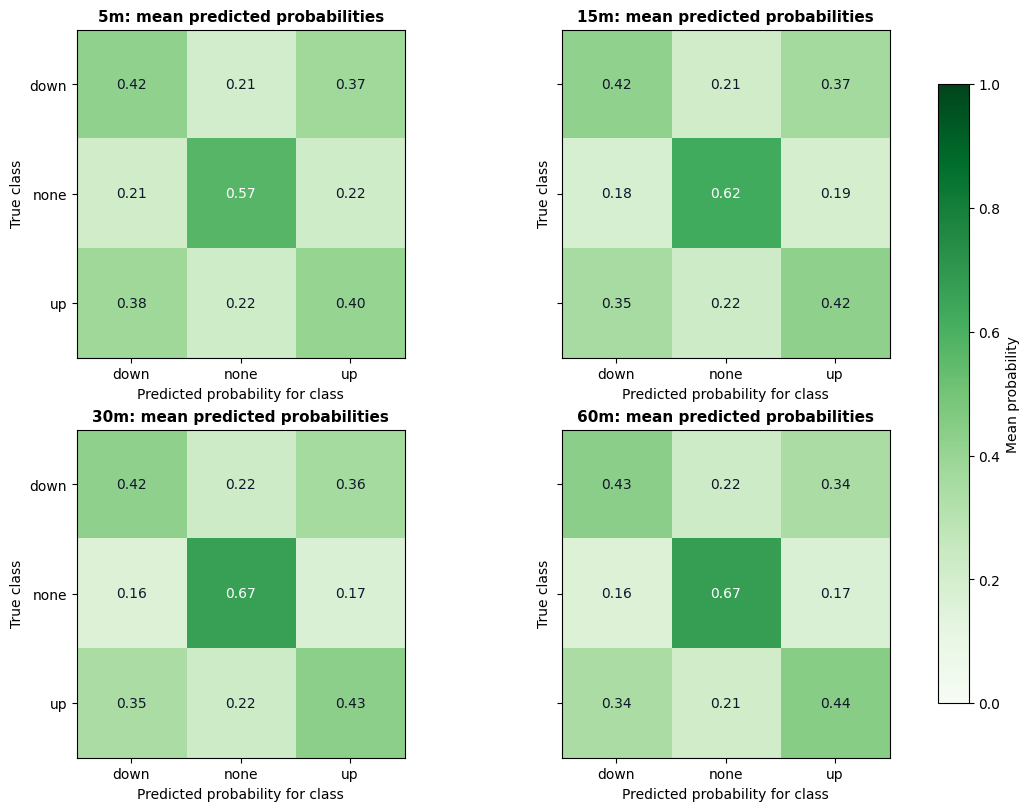

In [8]:
# Cell 7 - Evaluation with publication-quality figures
os.makedirs(FIGURE_DIR, exist_ok=True)
checkpoint_path = next((p for p in [BEST_CHECKPOINT_PATH, LEGACY_CHECKPOINT_PATH] if os.path.exists(p)), None)
if checkpoint_path is None:
    raise FileNotFoundError('No checkpoint found. Expected BEST_CHECKPOINT_PATH or LEGACY_CHECKPOINT_PATH.')
BEST_CHECKPOINT_PATH = checkpoint_path
checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=device,weights_only=False)
FEATURE_MEAN = checkpoint.get('feature_mean', FEATURE_MEAN)
FEATURE_STD = checkpoint.get('feature_std', FEATURE_STD)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()
print(f'Loaded checkpoint: {BEST_CHECKPOINT_PATH}')
print(f'Figures will be saved to: {FIGURE_DIR}')

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == 'cuda',
    persistent_workers=NUM_WORKERS > 0,
)

all_preds = []
all_labels = []
all_probs = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda' and USE_AMP)):
            logits = model(x)
            probs = torch.softmax(logits, dim=-1)
        all_preds.append(logits.argmax(dim=-1).cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y.numpy())

y_pred = np.concatenate(all_preds, axis=0)
y_prob = np.concatenate(all_probs, axis=0)
y_true = np.concatenate(all_labels, axis=0)

plt.style.use('default')
COLORS = {'down': '#b91c1c', 'none': '#334155', 'up': '#15803d'}
CLASS_COLORS = [COLORS['down'], COLORS['none'], COLORS['up']]

def savefig(fig, name):
    png_path = os.path.join(FIGURE_DIR, f'{name}.png')
    pdf_path = os.path.join(FIGURE_DIR, f'{name}.pdf')
    fig.savefig(png_path, dpi=220, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    print(f'Saved {png_path}')
    print(f'Saved {pdf_path}')

summary_rows = []
class_metric_rows = []
conf_mats = {}
conf_mats_norm = {}
distribution_rows = []

for h_idx, horizon in enumerate(HORIZON_NAMES):
    report = classification_report(
        y_true[:, h_idx],
        y_pred[:, h_idx],
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    acc = accuracy_score(y_true[:, h_idx], y_pred[:, h_idx])
    macro_f1 = report['macro avg']['f1-score']
    weighted_f1 = report['weighted avg']['f1-score']
    summary_rows.append({'horizon': horizon, 'accuracy': acc, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1})

    for cls in CLASS_NAMES:
        class_metric_rows.append({
            'horizon': horizon,
            'class': cls,
            'precision': report[cls]['precision'],
            'recall': report[cls]['recall'],
            'f1': report[cls]['f1-score'],
            'support': report[cls]['support'],
        })

    cm = confusion_matrix(y_true[:, h_idx], y_pred[:, h_idx], labels=[0, 1, 2])
    conf_mats[horizon] = cm
    conf_mats_norm[horizon] = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    true_counts = np.bincount(y_true[:, h_idx], minlength=3)[:3]
    pred_counts = np.bincount(y_pred[:, h_idx], minlength=3)[:3]
    for cls_idx, cls in enumerate(CLASS_NAMES):
        distribution_rows.append({'horizon': horizon, 'class': cls, 'kind': 'True', 'share': true_counts[cls_idx] / true_counts.sum()})
        distribution_rows.append({'horizon': horizon, 'class': cls, 'kind': 'Predicted', 'share': pred_counts[cls_idx] / pred_counts.sum()})

    print(f'\n=== Horizon {horizon} ===')
    print(f'Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f} | Weighted F1: {weighted_f1:.4f}')
    print(classification_report(y_true[:, h_idx], y_pred[:, h_idx], labels=[0, 1, 2], target_names=CLASS_NAMES, digits=4, zero_division=0))

summary = pd.DataFrame(summary_rows).set_index('horizon')
class_metrics = pd.DataFrame(class_metric_rows)
distributions = pd.DataFrame(distribution_rows)
print('\nSummary table:')
display(summary.T)
summary.to_csv(os.path.join(FIGURE_DIR, 'mamba_summary_metrics.csv'))
class_metrics.to_csv(os.path.join(FIGURE_DIR, 'mamba_class_metrics.csv'), index=False)

# Figure 1: normalized confusion matrices in a 2x2 grid.
fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
for ax, horizon in zip(axes.ravel(), HORIZON_NAMES):
    data = conf_mats_norm[horizon]
    im = ax.imshow(data, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{horizon} normalized confusion matrix', fontsize=12, weight='bold')
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('True class')
    ax.set_xticks(range(3), CLASS_NAMES)
    ax.set_yticks(range(3), CLASS_NAMES)
    raw = conf_mats[horizon]
    for i in range(3):
        for j in range(3):
            color = 'white' if data[i, j] > 0.55 else '#0f172a'
            ax.text(j, i, f'{data[i, j]:.1%}\n({raw[i, j]:,})', ha='center', va='center', color=color, fontsize=9)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85, label='Row-normalized share')
savefig(fig, 'mamba_confusion_matrices_normalized')
plt.show()

# Figure 2: headline metrics by horizon.
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(HORIZON_NAMES))
width = 0.25
for offset, metric, color in [(-width, 'accuracy', '#2563eb'), (0, 'macro_f1', '#7c3aed'), (width, 'weighted_f1', '#059669')]:
    vals = summary.loc[HORIZON_NAMES, metric].values
    bars = ax.bar(x + offset, vals, width, label=metric.replace('_', ' ').title(), color=color, alpha=0.9)
    ax.bar_label(bars, labels=[f'{v:.3f}' for v in vals], padding=3, fontsize=8)
ax.set_xticks(x, HORIZON_NAMES)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_xlabel('Prediction horizon')
ax.set_title('Mamba Test Performance by Horizon', fontsize=13, weight='bold')
ax.legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.12))
ax.grid(axis='y', alpha=0.25)
savefig(fig, 'mamba_summary_metrics')
plt.show()

# Figure 3: per-class F1 by horizon.
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(HORIZON_NAMES))
width = 0.24
for idx, cls in enumerate(CLASS_NAMES):
    vals = class_metrics[class_metrics['class'] == cls].set_index('horizon').loc[HORIZON_NAMES, 'f1'].values
    ax.bar(x + (idx - 1) * width, vals, width, label=cls, color=CLASS_COLORS[idx], alpha=0.9)
ax.set_xticks(x, HORIZON_NAMES)
ax.set_ylim(0, 1)
ax.set_ylabel('F1 score')
ax.set_xlabel('Prediction horizon')
ax.set_title('Per-Class F1 Scores', fontsize=13, weight='bold')
ax.legend(title='Class', frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.12))
ax.grid(axis='y', alpha=0.25)
savefig(fig, 'mamba_per_class_f1')
plt.show()

# Figure 4: true vs predicted class shares.
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True, constrained_layout=True)
for ax, horizon in zip(axes, HORIZON_NAMES):
    sub = distributions[distributions['horizon'] == horizon]
    for k_idx, kind in enumerate(['True', 'Predicted']):
        vals = sub[sub['kind'] == kind].set_index('class').loc[CLASS_NAMES, 'share'].values
        ax.bar(np.arange(3) + (k_idx - 0.5) * 0.36, vals, width=0.34, label=kind, color=['#94a3b8', '#0f172a'][k_idx], alpha=0.9)
    ax.set_title(horizon, weight='bold')
    ax.set_xticks(range(3), CLASS_NAMES, rotation=30)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.25)
axes[0].set_ylabel('Share of examples')
axes[0].legend(frameon=False, loc='upper left')
fig.suptitle('True vs Predicted Class Distribution', fontsize=14, weight='bold')
savefig(fig, 'mamba_class_distribution')
plt.show()

# Figure 5: mean predicted probability by true class, useful for calibration discussion.
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True, sharey=True)
for ax, h_idx, horizon in zip(axes.ravel(), range(4), HORIZON_NAMES):
    means = []
    for true_cls in range(3):
        mask = y_true[:, h_idx] == true_cls
        means.append(y_prob[mask, h_idx, :].mean(axis=0) if mask.any() else np.zeros(3))
    means = np.vstack(means)
    im = ax.imshow(means, cmap='Greens', vmin=0, vmax=1)
    ax.set_title(f'{horizon}: mean predicted probabilities', fontsize=11, weight='bold')
    ax.set_xlabel('Predicted probability for class')
    ax.set_ylabel('True class')
    ax.set_xticks(range(3), CLASS_NAMES)
    ax.set_yticks(range(3), CLASS_NAMES)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{means[i, j]:.2f}', ha='center', va='center', color='white' if means[i, j] > 0.5 else '#0f172a')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85, label='Mean probability')
savefig(fig, 'mamba_mean_probabilities_by_true_class')
plt.show()

In [9]:
# Cell 8 - Inference example
def predict(trades_df, ticker, model, device, feature_cols=FEATURE_COLUMNS, seq_len=SEQ_LEN, feature_mean=None, feature_std=None):
    """Run one live-style prediction from the last seq_len trades for one ticker.

    trades_df must already contain the same precomputed feature columns used for training.
    This function does not compute, resample, aggregate, or fill any features.
    """
    ticker_df = trades_df.loc[trades_df['ticker'] == ticker].sort_values('created_time', kind='mergesort')
    if len(ticker_df) < seq_len:
        raise ValueError(f'Need at least {seq_len} trades for ticker {ticker}; got {len(ticker_df)}.')

    missing = [c for c in feature_cols if c not in ticker_df.columns]
    if missing:
        raise ValueError(f'Missing feature columns: {missing}')

    window = ticker_df.tail(seq_len)
    x = window[feature_cols].to_numpy(dtype=np.float32, copy=True)
    if feature_mean is None:
        feature_mean = FEATURE_MEAN
    if feature_std is None:
        feature_std = FEATURE_STD
    x = (x - np.asarray(feature_mean, dtype=np.float32)) / np.asarray(feature_std, dtype=np.float32)
    x = torch.from_numpy(x).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda' and USE_AMP)):
            logits = model(x)
        probs = torch.softmax(logits, dim=-1).squeeze(0).detach().cpu().numpy()

    results = {}
    for h_idx, horizon in enumerate(HORIZON_NAMES):
        pred_idx = int(probs[h_idx].argmax())
        results[horizon] = {
            'predicted_class': CLASS_NAMES[pred_idx],
            'prob_down': float(probs[h_idx, 0]),
            'prob_none': float(probs[h_idx, 1]),
            'prob_up': float(probs[h_idx, 2]),
        }
        print(
            f"{horizon}: {CLASS_NAMES[pred_idx]} | "
            f"down={probs[h_idx, 0]:.4f}, none={probs[h_idx, 1]:.4f}, up={probs[h_idx, 2]:.4f}"
        )
    return results

# Example after training/evaluation:
sample_ticker = test_df['ticker'].iloc[0]
predictions = predict(test_df, sample_ticker, model, device)

5m: none | down=0.0017, none=0.9903, up=0.0080
15m: none | down=0.0004, none=0.9959, up=0.0037
30m: none | down=0.0004, none=0.9974, up=0.0022
60m: none | down=0.0001, none=0.9949, up=0.0050


In [11]:
# Cell 9 - Export all-trades raw logits to parquet
# Produces one row per valid same-ticker prediction window ending at created_time.
# Column names use the requested probability_* schema, but values are raw logits.
# Fast path: sort once, build valid same-ticker windows globally, and run large GPU batches.
import time
import shutil
import pyarrow as pa
import pyarrow.parquet as pq

MODEL_NAME = 'mamba'
HORIZON_MINUTES = [5, 15, 30, 60]
EXPORT_CLASS_ORDER = [('no_jump', 1), ('up', 2), ('down', 0)]  # model class order is [down, none/no_jump, up]
EXPORT_BATCH_SIZE = 16384  # Larger batches = better GPU utilization and fewer parquet row-group writes.
EXPORT_STRIDE = 1        # 1 = every valid trade row. Increase to reduce output size.
EXPORT_MAX_ROWS = None   # Set an int for a capped smoke/full run; None exports everything.
PREDICTION_OUTPUT_PATH = '/content/drive/MyDrive/CS1090B/project/predictions/mamba_all_trades_logits.parquet'

checkpoint_path = next((p for p in [BEST_CHECKPOINT_PATH, LEGACY_CHECKPOINT_PATH] if os.path.exists(p)), None)
if checkpoint_path is None:
    raise FileNotFoundError('No Mamba checkpoint found. Expected BEST_CHECKPOINT_PATH or LEGACY_CHECKPOINT_PATH.')
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
if 'feature_mean' in checkpoint and 'feature_std' in checkpoint:
    FEATURE_MEAN = checkpoint['feature_mean']
    FEATURE_STD = checkpoint['feature_std']
elif 'FEATURE_MEAN' not in globals() or 'FEATURE_STD' not in globals():
    raise KeyError('Checkpoint is missing feature_mean/feature_std and no FEATURE_MEAN/FEATURE_STD globals exist.')
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()
print(f'Loaded checkpoint for export: {checkpoint_path}')

expected_output_columns = ['ticker', 'created_time'] + [
    f'probability_{class_name}_{horizon_min}minutes_{MODEL_NAME}'
    for horizon_min in HORIZON_MINUTES
    for class_name, _ in EXPORT_CLASS_ORDER
]


def _table_from_logits(ticker_values, created_values, end_positions, logits, model_name):
    data = {
        'ticker': pa.array(ticker_values[end_positions]),
        'created_time': pa.array(created_values[end_positions]),
    }
    for h_idx, horizon_min in enumerate(HORIZON_MINUTES):
        for class_name, class_idx in EXPORT_CLASS_ORDER:
            data[f'probability_{class_name}_{horizon_min}minutes_{model_name}'] = pa.array(logits[:, h_idx, class_idx])
    return pa.table(data)


def _prepare_fast_export_arrays(trades_df, feature_cols, seq_len, feature_mean, feature_std, export_stride):
    t0 = time.time()
    feature_mean = np.asarray(feature_mean, dtype=np.float32)
    feature_std = np.asarray(feature_std, dtype=np.float32)
    if len(feature_mean) != len(feature_cols) or len(feature_std) != len(feature_cols):
        raise ValueError(
            f'Feature stat length mismatch: mean={len(feature_mean)}, std={len(feature_std)}, features={len(feature_cols)}'
        )
    if np.any(~np.isfinite(feature_mean)) or np.any(~np.isfinite(feature_std)):
        raise ValueError('Feature normalization stats contain NaN or inf.')
    if np.any(feature_std == 0):
        raise ValueError('Feature normalization std contains zero values.')
    if export_stride < 1:
        raise ValueError('EXPORT_STRIDE must be >= 1.')

    print('Sorting trades by ticker/created_time...')
    frame = trades_df.sort_values(['ticker', 'created_time'], kind='mergesort').reset_index(drop=True)
    n_rows = len(frame)
    print(f'Sorted {n_rows:,} rows in {(time.time() - t0) / 60:.2f} min')

    print('Building normalized feature matrix...')
    features = frame[feature_cols].to_numpy(dtype=np.float32, copy=True)
    features -= feature_mean
    features /= feature_std
    valid_rows = np.isfinite(features).all(axis=1)
    valid_prefix = np.concatenate([[0], np.cumsum(valid_rows, dtype=np.int32)])
    print(f'Feature matrix shape: {features.shape}; finite rows: {valid_rows.sum():,}')

    print('Vectorizing valid same-ticker window endpoints...')
    ticker_codes = pd.factorize(frame['ticker'], sort=False)[0]
    change_points = np.where(np.diff(ticker_codes) != 0)[0] + 1
    group_starts = np.concatenate([[0], change_points])
    group_ends = np.concatenate([change_points, [n_rows]])

    end_chunks = []
    for s, e in zip(group_starts, group_ends):
        if e - s < seq_len:
            continue
        end_pos = np.arange(s + seq_len - 1, e, export_stride, dtype=np.int64)
        start_pos = end_pos - seq_len + 1
        valid_windows = (valid_prefix[end_pos + 1] - valid_prefix[start_pos]) == seq_len
        if valid_windows.any():
            end_chunks.append(end_pos[valid_windows])

    if not end_chunks:
        raise ValueError('No valid prediction windows were found in all_trades_features.')
    end_positions = np.concatenate(end_chunks)
    if EXPORT_MAX_ROWS is not None:
        end_positions = end_positions[:int(EXPORT_MAX_ROWS)]
    print(f'Prepared {len(end_positions):,} prediction windows in {(time.time() - t0) / 60:.2f} min')

    ticker_values = frame['ticker'].astype(str).to_numpy(copy=False)
    created_values = frame['created_time'].to_numpy(copy=False)
    return features, ticker_values, created_values, end_positions


def export_all_trade_logits_to_parquet_fast(
    trades_df,
    model,
    output_path,
    model_name,
    feature_cols=FEATURE_COLUMNS,
    seq_len=SEQ_LEN,
    feature_mean=FEATURE_MEAN,
    feature_std=FEATURE_STD,
    batch_size=EXPORT_BATCH_SIZE,
    export_stride=EXPORT_STRIDE,
    report_every=1_000_000,
):
    if not output_path.startswith('/content/drive/MyDrive/'):
        raise ValueError(f'Output path should be on Google Drive, got: {output_path}')
    missing = [c for c in ['ticker', 'created_time', *feature_cols] if c not in trades_df.columns]
    if missing:
        raise ValueError(f'Missing required export columns: {missing}')

    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # Write the temp file to local /content/ SSD to avoid thousands of slow Drive FUSE writes.
    # A single shutil.move at the end copies the finished file to Drive.
    local_tmp = '/content/' + os.path.basename(output_path) + '.tmp'
    smoke_path = '/content/' + os.path.basename(output_path) + '.smoke_test.parquet'
    for stale_path in [local_tmp, smoke_path]:
        if os.path.exists(stale_path):
            os.remove(stale_path)

    free_gb = shutil.disk_usage('/content').free / 1e9
    print(f'Local /content free disk before export: {free_gb:.1f} GB')
    print(f'Export stride={export_stride}, max_rows={EXPORT_MAX_ROWS}, batch_size={batch_size}')

    features, ticker_values, created_values, end_positions = _prepare_fast_export_arrays(
        trades_df=trades_df,
        feature_cols=feature_cols,
        seq_len=seq_len,
        feature_mean=feature_mean,
        feature_std=feature_std,
        export_stride=export_stride,
    )

    window_offsets = np.arange(seq_len, dtype=np.int64)
    writer = None
    total_rows = 0
    next_report = report_every
    t0 = time.time()

    model.eval()
    try:
        with torch.no_grad():
            for batch_start in range(0, len(end_positions), batch_size):
                batch_end_positions = end_positions[batch_start:batch_start + batch_size]
                rows = batch_end_positions[:, None] - seq_len + 1 + window_offsets[None, :]
                x = torch.from_numpy(features[rows]).to(device, non_blocking=device.type == 'cuda')
                with torch.amp.autocast('cuda', enabled=(device.type == 'cuda' and USE_AMP)):
                    logits = model(x).detach().cpu().numpy().astype(np.float32)
                if logits.shape != (len(batch_end_positions), len(HORIZON_MINUTES), len(CLASS_NAMES)):
                    raise ValueError(f'Unexpected logits shape: {logits.shape}')

                table = _table_from_logits(ticker_values, created_values, batch_end_positions, logits, model_name)
                if table.column_names != expected_output_columns:
                    raise ValueError(f'Unexpected output columns: {table.column_names}')

                if writer is None:
                    pq.write_table(table.slice(0, min(10, table.num_rows)), smoke_path, compression='snappy')
                    smoke_table = pq.read_table(smoke_path)
                    if smoke_table.column_names != expected_output_columns:
                        raise ValueError(f'Smoke-test parquet columns changed: {smoke_table.column_names}')
                    os.remove(smoke_path)
                    print('Parquet smoke test passed.')
                    writer = pq.ParquetWriter(local_tmp, table.schema, compression='snappy')

                writer.write_table(table)
                total_rows += table.num_rows
                if total_rows >= next_report:
                    elapsed = (time.time() - t0) / 60
                    rate = total_rows / max(elapsed * 60, 1e-9)
                    print(f'Wrote {total_rows:,} prediction rows in {elapsed:.1f} min ({rate:,.0f} rows/sec)...')
                    next_report += report_every
    finally:
        if writer is not None:
            writer.close()

    if total_rows == 0:
        if os.path.exists(local_tmp):
            os.remove(local_tmp)
        raise ValueError('No rows were written to the prediction parquet.')

    print(f'Inference done: {total_rows:,} rows in {(time.time() - t0) / 60:.2f} min. Copying to Drive...')
    copy_start = time.time()
    if os.path.exists(output_path):
        os.remove(output_path)
    shutil.move(local_tmp, output_path)
    print(f'Copied to Drive in {(time.time() - copy_start) / 60:.2f} min: {output_path}')
    return output_path


# Validate the parquet schema before loading the full table into memory.
parquet_schema = pq.ParquetFile(PARQUET_PATH).schema_arrow
missing_in_file = [c for c in ['ticker', 'created_time', *FEATURE_COLUMNS] if c not in parquet_schema.names]
if missing_in_file:
    raise ValueError(f'Missing columns in PARQUET_PATH: {missing_in_file}')

all_trades_for_export = pd.read_parquet(PARQUET_PATH, columns=['ticker', 'created_time', *FEATURE_COLUMNS])
export_path = export_all_trade_logits_to_parquet_fast(
    all_trades_for_export,
    model=model,
    output_path=PREDICTION_OUTPUT_PATH,
    model_name=MODEL_NAME,
)
del all_trades_for_export
gc.collect()
print(export_path)

Loaded checkpoint for export: /content/drive/MyDrive/CS1090B/project/checkpoints/mamba_best.pt
Local /content free disk before export: 203.1 GB
Export stride=1, max_rows=None, batch_size=16384
Sorting trades by ticker/created_time...
Sorted 63,801,798 rows in 0.32 min
Building normalized feature matrix...
Feature matrix shape: (63801798, 40); finite rows: 54,391,664
Vectorizing valid same-ticker window endpoints...
Prepared 44,267,126 prediction windows in 0.39 min
Parquet smoke test passed.
Wrote 1,015,808 prediction rows in 0.1 min (201,076 rows/sec)...
Wrote 2,015,232 prediction rows in 0.2 min (212,265 rows/sec)...
Wrote 3,014,656 prediction rows in 0.2 min (216,646 rows/sec)...
Wrote 4,014,080 prediction rows in 0.3 min (219,220 rows/sec)...
Wrote 5,013,504 prediction rows in 0.4 min (220,807 rows/sec)...
Wrote 6,012,928 prediction rows in 0.5 min (222,006 rows/sec)...
Wrote 7,012,352 prediction rows in 0.5 min (222,943 rows/sec)...
Wrote 8,011,776 prediction rows in 0.6 min (223,